Model

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [6]:
df = pd.read_csv("../data/processed_sms.csv")

df['message_final'] = df['message_final'].fillna('').astype(str)

In [7]:
df['message_final'].apply(type).value_counts()

message_final
<class 'str'>    5572
Name: count, dtype: int64

In [8]:
cv = CountVectorizer()

X = cv.fit_transform(df['message_final'])

In [9]:
encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['label'])

In [10]:
y = df['label']

In [11]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Naive Bayes

In [12]:
model = MultinomialNB()

model.fit(x_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [13]:
y_predict = model.predict(x_test)

In [14]:
accuracy_score(y_test, y_predict)

0.9748878923766816

In [15]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       966
           1       0.87      0.95      0.91       149

    accuracy                           0.97      1115
   macro avg       0.93      0.97      0.95      1115
weighted avg       0.98      0.97      0.98      1115



Logistic Regression

In [16]:
log_model = LogisticRegression()

In [17]:
log_model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
y_predict_log = log_model.predict(x_test)

In [19]:
accuracy_score(y_test, y_predict_log)

0.9847533632286996

In [20]:
print(classification_report(y_test,y_predict_log))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.89      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.97      1115
weighted avg       0.99      0.98      0.98      1115



Confusion Matrix

In [22]:
cm = confusion_matrix(y_test, y_predict_log)

cm

array([[966,   0],
       [ 17, 132]])

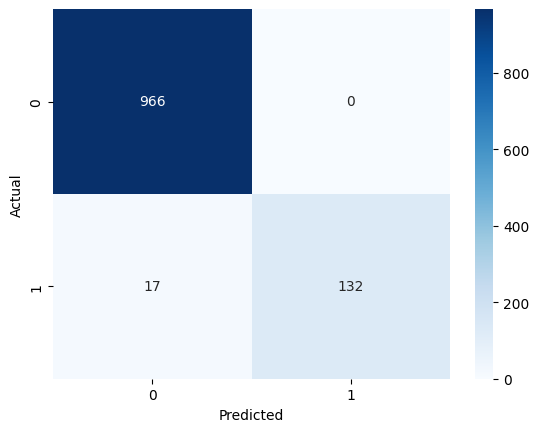

In [24]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()